# Notebook 02 — Solo Farmer Optimisation

**Purpose:** For each farmer acting independently, solve a Mixed-Integer Linear Programme
(MILP) to find their optimal carbon sequestration practice portfolio and standalone value
`ṽ({i})`.

The standalone value is the **individual rationality floor** used in every downstream
allocation mechanism: no farmer will accept a coalition payoff below this number.

---
**Reads:**  `data/processed/optimization_inputs.pkl`

**Writes:** `data/processed/standalone_values.pkl`

---
### Model summary

**Decision variables (per farmer):**
- `x[j]` ∈ {0,1} — adopt practice j?
- `z[j,k]` ∈ {0,1} for compatible pairs j < k — linearisation of `x[j] · x[k]`

**Objective (maximise net seasonal profit):**
```
FS_i · [Σ_j CSP_j·x_j  +  Σ_{j<k} α_jk·z_jk] · CCP        ← carbon revenue
+ FS_i · PADDY · [Σ_j γ̃_j·x_j  +  Σ_{j<k} γ_jk·z_jk]      ← yield revenue
− FS_i · [Σ_j OC_j·x_j  +  Σ_{j<k} β_jk·z_jk]              ← operational cost
− FIXED_MRV − VARIABLE_MRV · FS_i^δ                          ← MRV cost (fixed)
− FIXED_T   − VARIABLE_T                                      ← transaction cost
```

**Constraints:**
1. **Budget:** `FS_i·OC(x) + C_MRV_solo + C_T_solo ≤ B_i`
2. **Incompatibility:** `x[j] + x[k] ≤ 1` for all pairs where `Δ_jk = 1`
3. **Linearisation** for each compatible pair j < k:
   `z_jk ≤ x_j`,  `z_jk ≤ x_k`,  `z_jk ≥ x_j + x_k − 1`
4. **Binary:** `x[j], z[j,k] ∈ {0,1}`

## 0. Imports and configuration

In [4]:
import sys
import pickle
import time
from pathlib import Path
from typing import Dict, Any

import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB

sys.path.insert(0, str(Path.cwd()))
import config

Path(config.PROCESSED_DIR).mkdir(parents=True, exist_ok=True)

print(config.PROCESSED_DIR_PATH)

/data1/home/rohitsuresh/CGT_Carbon_farming/data/processed/Experiment_CF1_DELTA0


## 1. Load processed inputs

In [5]:
with open(config.INPUTS_PKL, "rb") as f:
    inp = pickle.load(f)

farmers_df      = inp["farmers_15"]          # use 15-farmer dataset
practices_df    = inp["practices"]
practice_names  = inp["practice_names"]      # ordered list, length M
practice_index  = inp["practice_index"]      # name → int index
Alpha           = inp["Alpha"]               # (M,M) sequestration synergies
Beta            = inp["Beta"]                # (M,M) cost interactions
Gamma           = inp["Gamma"]               # (M,M) yield interactions
Delta           = inp["Delta"]               # (M,M) incompatibility flags
incompatible    = inp["incompatible_pairs"]  # [(j,k,name_j,name_k), ...]
cfg             = inp["config"]              # economic parameter snapshot

M = len(practice_names)   # number of practices
N = len(farmers_df)       # number of farmers

# Pull practice-level arrays from the DataFrame (ordered by practice_names)
CSP_base  = practices_df.set_index("Practice").reindex(practice_names)["Net_CSP_base"].values
OC_base   = practices_df.set_index("Practice").reindex(practice_names)["Net_OC_per_ha"].values
YLD_base  = practices_df.set_index("Practice").reindex(practice_names)["Base_yield_change"].values

# Pre-compute list of compatible pairs (j < k, Delta[j,k] == 0)
# These are the only pairs that need a z[j,k] linearisation variable.
compatible_pairs = [
    (j, k)
    for j in range(M)
    for k in range(j + 1, M)
    if Delta[j, k] == 0
]
# Incompatible pairs as (j, k) tuples for fast iteration
incompat_pairs = [(j, k) for j, k, _, _ in incompatible]

print(f"Farmers          : {N}")
print(f"Practices        : {M}")
print(f"Compatible pairs : {len(compatible_pairs)}")
print(f"Incompatible pairs: {len(incompat_pairs)}")

Farmers          : 15
Practices        : 20
Compatible pairs : 188
Incompatible pairs: 2


## 2. Helper — compute fixed certification costs for a solo farmer

In [6]:
def solo_certification_cost(farm_size_ha: float) -> tuple[float, float]:
    """
    Return (C_MRV, C_T) for a solo farmer with the given farm size.

    These are FIXED costs that do not depend on the practice portfolio.
    They enter the objective as constants and the budget constraint as constants.
    """
    c_mrv = cfg["FIXED_MRV"] + cfg["VARIABLE_MRV"] * (farm_size_ha ** cfg["DELTA_MRV"])
    c_t   = cfg["FIXED_T"]   + cfg["VARIABLE_T"]   # |S| = 1
    return c_mrv, c_t

## 3. Core solver — single farmer MILP

In [ ]:
def solve_solo_farmer(
    farmer_id: str,
    farm_size: float,
    budget: float,
) -> Dict[str, Any]:
    """
    Solve the solo optimisation MILP for one farmer.

    Parameters
    ----------
    farmer_id  : string identifier (e.g. 'F0001')
    farm_size  : farm size in hectares (FS_i)
    budget     : total capital available, INR/season (B_i)

    Returns
    -------
    dict with keys:
        farmer_id          : str
        farm_size          : float
        budget             : float
        status             : 'optimal' | 'infeasible' | 'other'
        portfolio          : list[str]  — adopted practice names
        portfolio_idx      : list[int]  — adopted practice indices
        raw_obj_value      : float  — Gurobi objective (may be negative)
        standalone_value   : float  — max(raw_obj_value, 0); IR floor
        sequestration_tco2 : float  — total tCO2e/season
        oc_inr             : float  — total operational cost INR/season
        yield_rev_inr      : float  — yield revenue change INR/season
        carbon_rev_inr     : float  — carbon credit revenue INR/season
        c_mrv              : float  — MRV cost INR/season
        c_t                : float  — transaction cost INR/season
        n_practices        : int
        solve_time_s       : float
    """
    t0 = time.perf_counter()
    FS = farm_size
    B  = budget
    c_mrv, c_t = solo_certification_cost(FS)
    fixed_cert  = c_mrv + c_t   # constant; does not depend on x

    # ------------------------------------------------------------------
    # Early infeasibility check:
    # Even the empty portfolio requires paying fixed certification costs.
    # If B < fixed_cert, no portfolio (including empty) is budget-feasible.
    # ------------------------------------------------------------------
    if B < fixed_cert:
        return {
            "farmer_id"          : farmer_id,
            "farm_size"          : FS,
            "budget"             : B,
            "status"             : "infeasible",
            "portfolio"          : [],
            "portfolio_idx"      : [],
            "raw_obj_value"      : 0.0,
            "standalone_value"   : 0.0,
            "sequestration_tco2" : 0.0,
            "oc_inr"             : 0.0,
            "yield_rev_inr"      : 0.0,
            "carbon_rev_inr"     : 0.0,
            "c_mrv"              : c_mrv,
            "c_t"                : c_t,
            "n_practices"        : 0,
            "solve_time_s"       : time.perf_counter() - t0,
        }

    # ------------------------------------------------------------------
    # Build Gurobi model
    # ------------------------------------------------------------------
    env = gp.Env(empty=True)
    env.setParam("OutputFlag",  config.GUROBI_OUTPUT_FLAG)
    env.setParam("TimeLimit",   config.GUROBI_TIME_LIMIT)
    env.setParam("MIPGap",      config.GUROBI_MIP_GAP)
    env.start()

    model = gp.Model(f"solo_{farmer_id}", env=env)
    model.setParam("OutputFlag", config.GUROBI_OUTPUT_FLAG)

    # ── Decision variables ────────────────────────────────────────────
    # x[j] ∈ {0,1}: adopt practice j?
    x = model.addVars(M, vtype=GRB.BINARY, name="x")

    # z[(j,k)] ∈ {0,1}: linearisation of x[j]*x[k] for compatible pairs only.
    # Incompatible pairs (Delta[j,k]=1) have x[j]+x[k]≤1 so their product is
    # always 0 — no z variable needed.
    z = model.addVars(compatible_pairs, vtype=GRB.BINARY, name="z")

    # ── Objective coefficients (pre-compute for readability) ───────────
    CCP         = cfg["CCP"]
    PADDY       = cfg["PADDY_PRICE"]

    # Linear terms: contribution of each practice j adopted alone
    # (carbon revenue + yield revenue − operational cost) per unit adoption
    # All scaled by FS because everything is expressed per-hectare in the data.
    linear_coeff = {
        j: FS * (
            CSP_base[j] * CCP           # carbon credit revenue
            + YLD_base[j] * PADDY       # yield revenue change
            - OC_base[j]                # operational cost (may be negative = saving)
        )
        for j in range(M)
    }

    # Quadratic (now linearised) terms: pairwise contribution of z[(j,k)]
    bilinear_coeff = {
        (j, k): FS * (
            Alpha[j, k] * CCP           # sequestration synergy
            + Gamma[j, k] * PADDY       # yield synergy
            - Beta[j, k]                # cost interaction (neg = saving)
        )
        for j, k in compatible_pairs
    }

    # Objective: maximise net profit
    # fixed_cert is subtracted as a constant (not a Gurobi variable)
    obj = (
        gp.quicksum(linear_coeff[j] * x[j] for j in range(M))
        + gp.quicksum(bilinear_coeff[(j, k)] * z[(j, k)] for j, k in compatible_pairs)
        - fixed_cert   # constant: MRV + transaction cost
    )
    model.setObjective(obj, GRB.MAXIMIZE)

    # ── Constraint 1: Budget ──────────────────────────────────────────
    # OC_i(x) - YR_i(x) + fixed_cert <= B_i
    # Rearranging: OC_i(x) - YR_i(x) <= B_i - fixed_cert
    
    oc_expr = (
        gp.quicksum(FS * OC_base[j] * x[j] for j in range(M))
        + gp.quicksum(FS * Beta[j, k] * z[(j, k)] for j, k in compatible_pairs)
    )
    
    yr_expr = (
        gp.quicksum(FS * PADDY * YLD_base[j] * x[j] for j in range(M))
        + gp.quicksum(FS * PADDY * Gamma[j, k] * z[(j, k)] for j, k in compatible_pairs)
    )



    # ── Solve ─────────────────────────────────────────────────────────
    model.optimize()

    # ── Extract solution ──────────────────────────────────────────────
    status = model.Status

    if status == GRB.OPTIMAL:
        x_vals = {j: round(x[j].X) for j in range(M)}
        z_vals = {(j, k): round(z[(j, k)].X) for j, k in compatible_pairs}

        adopted_idx  = [j for j in range(M) if x_vals[j] == 1]
        adopted_names = [practice_names[j] for j in adopted_idx]

        # Re-compute quantities from solution values (for reporting)
        seq = FS * (
            sum(CSP_base[j]       for j in adopted_idx)
            + sum(Alpha[j, k] * z_vals[(j, k)] for j, k in compatible_pairs)
        )
        oc = FS * (
            sum(OC_base[j]        for j in adopted_idx)
            + sum(Beta[j, k]  * z_vals[(j, k)] for j, k in compatible_pairs)
        )
        yr = FS * PADDY * (
            sum(YLD_base[j]       for j in adopted_idx)
            + sum(Gamma[j, k] * z_vals[(j, k)] for j, k in compatible_pairs)
        )
        cr = seq * CCP

        raw_obj = model.ObjVal

        # Individual rationality floor:
        # If optimal solo profit is negative the farmer is better off not
        # participating. Their outside option is 0 (no programme at all).
        ir_floor = max(raw_obj, 0.0)

        result = {
            "farmer_id"          : farmer_id,
            "farm_size"          : FS,
            "budget"             : B,
            "status"             : "optimal",
            "portfolio"          : adopted_names,
            "portfolio_idx"      : adopted_idx,
            "raw_obj_value"      : raw_obj,
            "standalone_value"   : ir_floor,
            "sequestration_tco2" : seq,
            "oc_inr"             : oc,
            "yield_rev_inr"      : yr,
            "carbon_rev_inr"     : cr,
            "c_mrv"              : c_mrv,
            "c_t"                : c_t,
            "n_practices"        : len(adopted_idx),
            "solve_time_s"       : time.perf_counter() - t0,
        }

    else:
        # Gurobi returned infeasible or other non-optimal status.
        # This path should be rare given the early check above, but is
        # possible if only some subsets of practices trigger infeasibility
        # through the budget constraint with positive OC practices.
        result = {
            "farmer_id"          : farmer_id,
            "farm_size"          : FS,
            "budget"             : B,
            "status"             : "infeasible" if status == GRB.INFEASIBLE else f"status_{status}",
            "portfolio"          : [],
            "portfolio_idx"      : [],
            "raw_obj_value"      : 0.0,
            "standalone_value"   : 0.0,
            "sequestration_tco2" : 0.0,
            "oc_inr"             : 0.0,
            "yield_rev_inr"      : 0.0,
            "carbon_rev_inr"     : 0.0,
            "c_mrv"              : c_mrv,
            "c_t"                : c_t,
            "n_practices"        : 0,
            "solve_time_s"       : time.perf_counter() - t0,
        }

    model.dispose()
    env.dispose()
    return result

## 4. Run solo optimisation for all farmers

In [8]:
standalone_values: Dict[str, Dict[str, Any]] = {}
total_t0 = time.perf_counter()

for _, row in farmers_df.iterrows():
    fid   = row["Farmer_ID"]
    fs    = row["Farm_Size_ha"]
    bud   = row["Budget_total_INR_per_season"]

    result = solve_solo_farmer(fid, fs, bud)
    standalone_values[fid] = result

    status_tag = result["status"]
    n_p        = result["n_practices"]
    sv         = result["standalone_value"]
    print(
        f"  {fid} | {fs:5.2f} ha | "
        f"budget {bud:>8,.0f} INR | "
        f"{status_tag:10s} | "
        f"{n_p:2d} practices | "
        f"ṽ = {sv:>10,.0f} INR"
    )

elapsed = time.perf_counter() - total_t0
print(f"\nAll {N} farmers solved in {elapsed:.2f} s")

  F0001 |  0.82 ha | budget    3,032 INR | infeasible |  0 practices | ṽ =          0 INR
  F0002 |  0.21 ha | budget      698 INR | infeasible |  0 practices | ṽ =          0 INR
  F0003 |  1.28 ha | budget    4,767 INR | infeasible |  0 practices | ṽ =          0 INR
  F0004 |  1.55 ha | budget    5,075 INR | infeasible |  0 practices | ṽ =          0 INR
  F0005 |  0.69 ha | budget    2,347 INR | infeasible |  0 practices | ṽ =          0 INR
  F0006 |  0.44 ha | budget    1,510 INR | infeasible |  0 practices | ṽ =          0 INR
  F0007 |  0.60 ha | budget    2,016 INR | infeasible |  0 practices | ṽ =          0 INR
  F0008 |  0.26 ha | budget      820 INR | infeasible |  0 practices | ṽ =          0 INR
  F0009 |  1.46 ha | budget    4,840 INR | infeasible |  0 practices | ṽ =          0 INR
  F0010 |  1.32 ha | budget    4,470 INR | infeasible |  0 practices | ṽ =          0 INR
  F0011 |  0.65 ha | budget    2,190 INR | infeasible |  0 practices | ṽ =          0 INR
  F0012 | 

## 5. Summary table — ranked by standalone value

In [9]:
rows = []
for fid, r in standalone_values.items():
    rows.append({
        "Farmer"          : fid,
        "Farm_ha"         : r["farm_size"],
        "Budget_INR"      : r["budget"],
        "Status"          : r["status"],
        "N_practices"     : r["n_practices"],
        "Seq_tCO2"        : round(r["sequestration_tco2"], 3),
        "Carbon_rev_INR"  : round(r["carbon_rev_inr"],    0),
        "Yield_rev_INR"   : round(r["yield_rev_inr"],     0),
        "OC_INR"          : round(r["oc_inr"],            0),
        "MRV_INR"         : round(r["c_mrv"],             0),
        "T_INR"           : round(r["c_t"],               0),
        "Raw_obj_INR"     : round(r["raw_obj_value"],     0),
        "Standalone_INR"  : round(r["standalone_value"],  0),
    })

summary_df = pd.DataFrame(rows).sort_values("Standalone_INR", ascending=False).reset_index(drop=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.width",       200)
pd.set_option("display.float_format", lambda x: f"{x:,.0f}")
display(summary_df)

,Farmer,Farm_ha,Budget_INR,Status,N_practices,Seq_tCO2,Carbon_rev_INR,Yield_rev_INR,OC_INR,MRV_INR,T_INR,Raw_obj_INR,Standalone_INR
0,F0001,1,"3,032",infeasible,0,0,0,0,0,"9,000",2500,0,0
1,F0002,0,698,infeasible,0,0,0,0,0,"9,000",2500,0,0
2,F0003,1,"4,767",infeasible,0,0,0,0,0,"9,000",2500,0,0
3,F0004,2,"5,075",infeasible,0,0,0,0,0,"9,000",2500,0,0
4,F0005,1,"2,347",infeasible,0,0,0,0,0,"9,000",2500,0,0
5,F0006,0,"1,510",infeasible,0,0,0,0,0,"9,000",2500,0,0
6,F0007,1,"2,016",infeasible,0,0,0,0,0,"9,000",2500,0,0
7,F0008,0,820,infeasible,0,0,0,0,0,"9,000",2500,0,0
8,F0009,1,"4,840",infeasible,0,0,0,0,0,"9,000",2500,0,0
9,F0010,1,"4,470",infeasible,0,0,0,0,0,"9,000",2500,0,0


## 6. Portfolio details — what each farmer actually adopts

In [10]:
print("Optimal portfolios (sorted by standalone value, highest first)\n")
print("=" * 70)

for _, row in summary_df.iterrows():
    fid   = row["Farmer"]
    r     = standalone_values[fid]
    sv    = r["standalone_value"]
    raw   = r["raw_obj_value"]
    port  = r["portfolio"]

    print(f"{fid}  ({r['farm_size']:.2f} ha)   ṽ = {sv:,.0f} INR", end="")
    if raw < 0:
        print(f"  [raw obj = {raw:,.0f} — solo participation unprofitable]", end="")
    print()

    if port:
        for p in port:
            j = practice_index[p]
            print(f"    [{j:2d}] {p}")
    else:
        print("    (no practices adopted — budget infeasible or unprofitable)")
    print("-" * 70)

Optimal portfolios (sorted by standalone value, highest first)

F0001  (0.82 ha)   ṽ = 0 INR
    (no practices adopted — budget infeasible or unprofitable)
----------------------------------------------------------------------
F0002  (0.21 ha)   ṽ = 0 INR
    (no practices adopted — budget infeasible or unprofitable)
----------------------------------------------------------------------
F0003  (1.28 ha)   ṽ = 0 INR
    (no practices adopted — budget infeasible or unprofitable)
----------------------------------------------------------------------
F0004  (1.55 ha)   ṽ = 0 INR
    (no practices adopted — budget infeasible or unprofitable)
----------------------------------------------------------------------
F0005  (0.69 ha)   ṽ = 0 INR
    (no practices adopted — budget infeasible or unprofitable)
----------------------------------------------------------------------
F0006  (0.44 ha)   ṽ = 0 INR
    (no practices adopted — budget infeasible or unprofitable)
-----------------------------

## 7. Verification checks

In [11]:
print("Verification checks")
print("-" * 50)

all_pass = True

for fid, r in standalone_values.items():
    if r["status"] != "optimal":
        continue

    FS  = r["farm_size"]
    B   = r["budget"]
    idx = r["portfolio_idx"]
    c_mrv, c_t = r["c_mrv"], r["c_t"]

    # ── Check 1: Budget constraint not violated ───────────────────────
    # Recompute OC from stored portfolio
    oc_recompute = FS * (
        sum(OC_base[j] for j in idx)
        + sum(
            Beta[j, k]
            for j in idx for k in idx
            if j < k and Delta[j, k] == 0
        )
    )
    budget_used = oc_recompute + c_mrv + c_t
    if budget_used > B + 1e-3:   # 1 rupee tolerance
        print(f"  FAIL [{fid}] budget exceeded: used={budget_used:,.0f}  B={B:,.0f}")
        all_pass = False

    # ── Check 2: No incompatible pair co-adopted ──────────────────────
    for j, k in incompat_pairs:
        if j in idx and k in idx:
            print(f"  FAIL [{fid}] incompatible pair co-adopted: "
                  f"{practice_names[j]} & {practice_names[k]}")
            all_pass = False

    # ── Check 3: standalone_value ≥ 0 ────────────────────────────────
    if r["standalone_value"] < -1e-3:
        print(f"  WARN [{fid}] standalone_value = {r['standalone_value']:,.0f} < 0 "
              f"(raw obj is negative; IR floor set to 0)")

if all_pass:
    print("  Budget constraint      : PASS (all farmers)")
    print("  Incompatibility        : PASS (all farmers)")

# ── Check 4: Efficiency — Σ components ≈ raw_obj ─────────────────────
print()
print("Component reconciliation check (carbon + yield − OC − MRV − T ≈ raw_obj):")
recon_ok = True
for fid, r in standalone_values.items():
    if r["status"] != "optimal":
        continue
    recon = r["carbon_rev_inr"] + r["yield_rev_inr"] - r["oc_inr"] - r["c_mrv"] - r["c_t"]
    diff  = abs(recon - r["raw_obj_value"])
    if diff > 1.0:   # 1 rupee tolerance
        print(f"  FAIL [{fid}] recon={recon:,.0f}  obj={r['raw_obj_value']:,.0f}  diff={diff:.2f}")
        recon_ok = False
if recon_ok:
    print("  All farmers reconcile correctly — PASS")

Verification checks
--------------------------------------------------
  Budget constraint      : PASS (all farmers)
  Incompatibility        : PASS (all farmers)

Component reconciliation check (carbon + yield − OC − MRV − T ≈ raw_obj):
  All farmers reconcile correctly — PASS


## 8. Diagnostic plots — standalone values and farm sizes

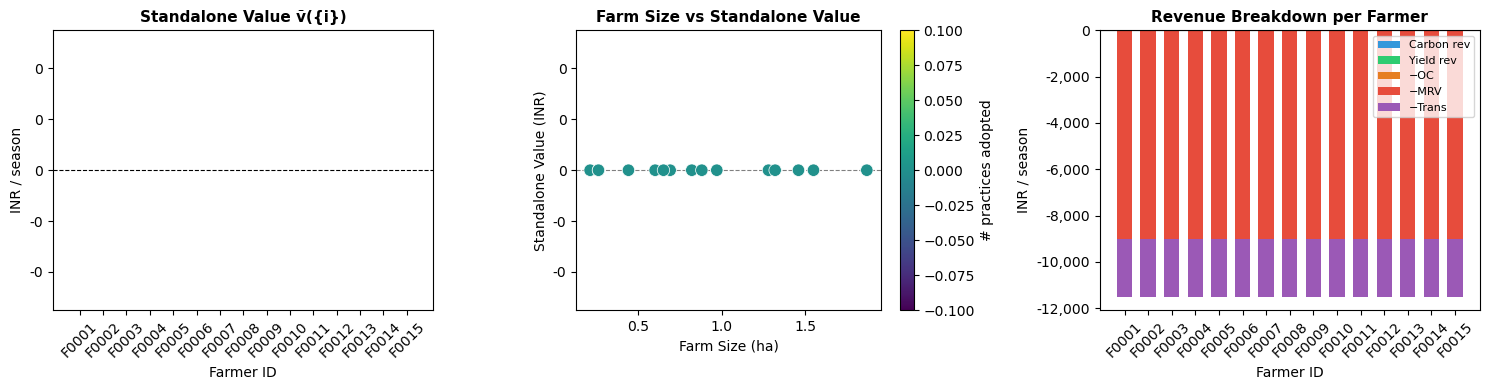

Figure saved.


In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sv_vals  = summary_df["Standalone_INR"].values
fs_vals  = summary_df["Farm_ha"].values
fids     = summary_df["Farmer"].values
n_p_vals = summary_df["N_practices"].values

# ── Plot 1: Standalone values bar chart ──────────────────────────────
ax = axes[0]
colors = ["#2ecc71" if v >= 0 else "#e74c3c" for v in sv_vals]
ax.bar(fids, sv_vals, color=colors, edgecolor="white", linewidth=0.5)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Standalone Value ṽ({i})", fontsize=11, fontweight="bold")
ax.set_ylabel("INR / season")
ax.set_xlabel("Farmer ID")
ax.tick_params(axis="x", rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# ── Plot 2: Farm size vs standalone value scatter ─────────────────────
ax = axes[1]
sc = ax.scatter(fs_vals, sv_vals, c=n_p_vals, cmap="viridis",
                s=80, edgecolors="white", linewidth=0.5, zorder=3)
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_title("Farm Size vs Standalone Value", fontsize=11, fontweight="bold")
ax.set_xlabel("Farm Size (ha)")
ax.set_ylabel("Standalone Value (INR)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.colorbar(sc, ax=ax, label="# practices adopted")

# ── Plot 3: Revenue breakdown stacked bar ─────────────────────────────
ax = axes[2]
cr_vals = summary_df["Carbon_rev_INR"].values
yr_vals = summary_df["Yield_rev_INR"].values
oc_neg  = -summary_df["OC_INR"].values          # flip sign for stacked bar
mrv_neg = -summary_df["MRV_INR"].values
t_neg   = -summary_df["T_INR"].values

bar_w = 0.65
ax.bar(fids, cr_vals,  bar_w, label="Carbon rev",   color="#3498db")
ax.bar(fids, yr_vals,  bar_w, bottom=cr_vals, label="Yield rev", color="#2ecc71")
ax.bar(fids, oc_neg,   bar_w, label="−OC",         color="#e67e22")
ax.bar(fids, mrv_neg,  bar_w, bottom=oc_neg, label="−MRV",  color="#e74c3c")
ax.bar(fids, t_neg,    bar_w, bottom=oc_neg + mrv_neg, label="−Trans", color="#9b59b6")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Revenue Breakdown per Farmer", fontsize=11, fontweight="bold")
ax.set_ylabel("INR / season")
ax.set_xlabel("Farmer ID")
ax.tick_params(axis="x", rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig(f"{config.PROCESSED_DIR}/nb02_solo_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

## 9. Key statistics

In [13]:
n_optimal     = sum(1 for r in standalone_values.values() if r["status"] == "optimal")
n_infeasible  = N - n_optimal
n_profitable  = sum(1 for r in standalone_values.values() if r["raw_obj_value"] > 0)
n_unprofitable = n_optimal - n_profitable

sv_array  = np.array([r["standalone_value"] for r in standalone_values.values()])
seq_array = np.array([r["sequestration_tco2"] for r in standalone_values.values()])

print("=" * 55)
print("SOLO OPTIMISATION SUMMARY")
print("=" * 55)
print(f"  Total farmers              : {N}")
print(f"  Optimal solves             : {n_optimal}")
print(f"  Budget-infeasible          : {n_infeasible}")
print(f"  Profitable solo (ṽ > 0)    : {n_profitable}")
print(f"  Unprofitable solo (ṽ = 0)  : {n_unprofitable}  ← motivate coalition")
print()
print(f"  Standalone value (INR/season):")
print(f"    Min    : {sv_array.min():>10,.0f}")
print(f"    Median : {np.median(sv_array):>10,.0f}")
print(f"    Mean   : {sv_array.mean():>10,.0f}")
print(f"    Max    : {sv_array.max():>10,.0f}")
print(f"    Total  : {sv_array.sum():>10,.0f}")
print()
print(f"  Total sequestration (solo)  : {seq_array.sum():.2f} tCO2e/season")
print("=" * 55)

SOLO OPTIMISATION SUMMARY
  Total farmers              : 15
  Optimal solves             : 0
  Budget-infeasible          : 15
  Profitable solo (ṽ > 0)    : 0
  Unprofitable solo (ṽ = 0)  : 0  ← motivate coalition

  Standalone value (INR/season):
    Min    :          0
    Median :          0
    Mean   :          0
    Max    :          0
    Total  :          0

  Total sequestration (solo)  : 0.00 tCO2e/season


## 10. Save standalone values pickle

In [14]:
out_path = Path(config.STANDALONE_PKL)
with open(out_path, "wb") as f:
    pickle.dump(standalone_values, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Saved: {out_path.resolve()}")
print(f"Keys  : {list(standalone_values.keys())}")
print(f"File size: {out_path.stat().st_size / 1024:.1f} KB")

Saved: /data1/home/rohitsuresh/CGT_Carbon_farming/data/processed/Experiment_CF1_DELTA0/standalone_values.pkl
Keys  : ['F0001', 'F0002', 'F0003', 'F0004', 'F0005', 'F0006', 'F0007', 'F0008', 'F0009', 'F0010', 'F0011', 'F0012', 'F0013', 'F0014', 'F0015']
File size: 2.4 KB


## 11. Reload and verify the pickle

In [15]:
with open(config.STANDALONE_PKL, "rb") as f:
    sv_loaded = pickle.load(f)

assert set(sv_loaded.keys()) == set(standalone_values.keys()), "Key mismatch"
for fid in standalone_values:
    assert sv_loaded[fid]["standalone_value"] == standalone_values[fid]["standalone_value"], \
        f"standalone_value mismatch for {fid}"

print("Pickle reload: all standalone values match")
print()


Pickle reload: all standalone values match

